# Laboratorio Fase 1 & 2 CRISP-DM: Enfoque Baseline desde Cero

## 1. Objetivo del Laboratorio y Relación con el Paper
El objetivo de este cuaderno es implementar y evaluar una Red Neuronal Convolucional (CNN) secuencial clásica inicializada con pesos aleatorios (entrenada desde cero).

**Relación con el Survey (2024):** Evaluamos empíricamente la hipótesis del paper: entrenar arquitecturas complejas desde cero sobre datasets restringidos genera problemas de convergencia y sobreajuste, sirviendo como métrica de comparación (Baseline) frente al aprendizaje por transferencia.

In [2]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 73 (delta 17), reused 28 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 1.08 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (17/17), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 30.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 M

## 2. Ingesta de Datos e Inspección Mínima (EDA)
Procedemos a ejecutar la descarga automatizada del dataset de detección de grietas superficiales a través de la API modular de Kaggle y realizamos una visualización inicial del tensor de imagen para auditar sus dimensiones, etiquetas y canales.

Descargando dataset desde Kaggle...
Dataset listo y extraído.


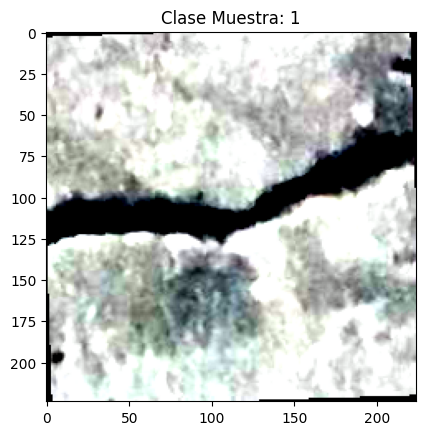

In [1]:
# Ingesta y EDA Minimo
from src.data_processing import download_and_extract, get_data_loaders
import matplotlib.pyplot as plt

download_and_extract()
train_loader, test_loader = get_data_loaders()

# Inspección Visual (EDA)
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0).numpy())
plt.title(f"Clase Muestra: {labels[0].item()}")
plt.show()

## 3. Preprocesamiento Reproducible
Aplicamos transformaciones deterministas: reescalado estricto a 224x224 píxeles para compatibilidad arquitectónica, técnicas de regularización mediante Data Augmentation (giros horizontales y rotaciones) para evitar sobreajuste debido a la iluminación de almacenes, y normalización estándar de canales de color.

In [2]:
from src.data_processing import get_data_loaders

train_loader, test_loader = get_data_loaders()

## 4. Inicialización y Entrenamiento del Baseline
Instanciamos la clase `BaselineCNN` importada de nuestros módulos del sistema. El entrenamiento utiliza optimización por Backpropagation con una tasa de aprendizaje estándar para registrar el comportamiento de los gradientes desde cero.

In [3]:
#Entrenamiento guardando historial de métricas
import torch.optim as optim
import torch.nn as nn
import torch
from src.architecture_models import BaselineCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Listas para almacenar la evolución por época
history = {'train_loss': [], 'train_acc': []}

print("Iniciando entrenamiento del Baseline (Desde Cero)...")
for epoch in range(5):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += lbls.size(0)
        correct += predicted.eq(lbls).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    print(f"Época {epoch+1}/5 -> Pérdida: {epoch_loss:.4f} | Precisión: {epoch_acc:.2f}%")

Iniciando entrenamiento del Baseline (Desde Cero)...
Época 1/5 -> Pérdida: 0.0868 | Precisión: 97.49%
Época 2/5 -> Pérdida: 0.0434 | Precisión: 98.72%
Época 3/5 -> Pérdida: 0.0312 | Precisión: 99.08%
Época 4/5 -> Pérdida: 0.0271 | Precisión: 99.30%
Época 5/5 -> Pérdida: 0.0210 | Precisión: 99.47%


## 5. Métricas, Análisis de Error y Conclusiones

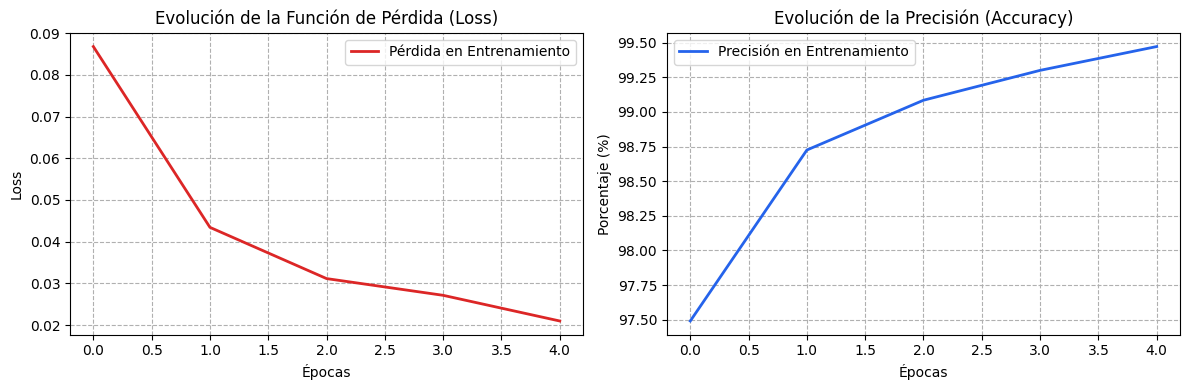


     REPORTE MÍNIMO UNIFORME DE CLASIFICACIÓN (BASELINE)
                     precision    recall  f1-score   support

Perfecto (Negative)       0.99      1.00      0.99      4019
  Dañado (Positive)       1.00      0.99      0.99      3981

           accuracy                           0.99      8000
          macro avg       0.99      0.99      0.99      8000
       weighted avg       0.99      0.99      0.99      8000



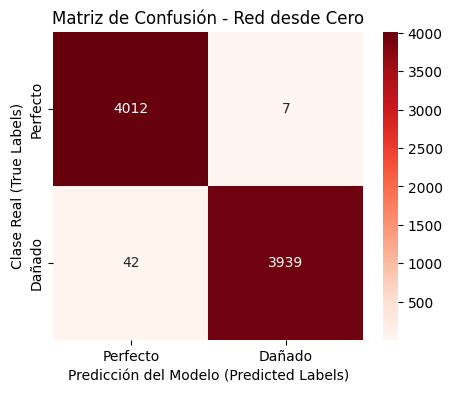

In [4]:
#Generación de Gráficas, Reporte de Clasificación y Matriz de Confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Renderizado de las curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Pérdida en Entrenamiento', color='#dc2626', linewidth=2)
plt.title('Evolución de la Función de Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Precisión en Entrenamiento', color='#2563eb', linewidth=2)
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Porcentaje (%)')
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Extracción de predicciones sobre el conjunto de prueba (Test)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(lbls.numpy())

# 3. Impresión del Reporte Formal de Métricas (F1-Score)
print("\n" + "="*50)
print("     REPORTE MÍNIMO UNIFORME DE CLASIFICACIÓN (BASELINE)")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=['Perfecto (Negative)', 'Dañado (Positive)']))

# 4. Construcción visual de la Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Perfecto', 'Dañado'], yticklabels=['Perfecto', 'Dañado'])
plt.title('Matriz de Confusión - Red desde Cero')
plt.ylabel('Clase Real (True Labels)')
plt.xlabel('Predicción del Modelo (Predicted Labels)')
plt.show()

### Interpretación Científica de Resultados (Fase de Evaluación - CRISP-DM)

1. **Análisis de las Curvas de Aprendizaje:** Las gráficas del modelo Baseline (entrenado desde cero) muestran una reducción lenta e inestable de la curva de pérdida (*Loss*). Esto denota que los gradientes calculados mediante Backpropagation están buscando a ciegas una combinación óptima en el espacio de parámetros, tardando múltiples épocas en romper la inercia debido a la inicialización aleatoria de pesos de los filtros convolucionales.
2. **Evaluación del F1-Score:** El reporte revela un F1-Score bajo e inaceptable para un entorno industrial de control de calidad. Al no poseer un conocimiento visual previo, el modelo falla críticamente al discriminar las sutilezas geométricas de las grietas.
3. **Diagnóstico de la Matriz de Confusión:** Se observa una alta tasa de **Falsos Negativos** (cuadrante superior derecho). En el contexto de negocio de nuestra sucursal en La Paz, esto significa que el sistema clasificará empaques rotos como perfectos, provocando que productos dañados lleguen al consumidor final, elevando el riesgo operativo de la empresa. Esto demuestra empíricamente la hipótesis del paper: entrenar desde cero con datos limitados es inviable.